# Nevronske mreže

V predavanju o linearnih modelih smo videli, da lahko linearno regresijo in linearni perceptron zapišemo z isto osnovno operacijo: z linearno kombinacijo napovednih spremenljivk. Za primer $\boldsymbol{x}$ in vektor uteži $\boldsymbol{w}$ je stanje izhodnega nevrona
$$
v = \boldsymbol{w}^T\boldsymbol{x},
$$
napoved pa je odvisna od funkcije aktivacije. Pri regresijskem perceptronu smo uporabili linearno funkcijo $\phi(v)=v$, zato je bil model še vedno linearen.

Nevronske mreže ta opis razširijo v dveh smereh. Prva je **kompozicija**: izhodi ene skupine nevronov postanejo vhodi naslednje skupine nevronov. Druga je **nelinearnost**: med zaporednimi linearnimi transformacijami uporabimo nelinearne funkcije aktivacije. Ravno kombinacija obeh idej omogoči, da mreža opiše odvisnosti, ki jih ena linearna odločitvena meja ali ena linearna regresijska funkcija ne more opisati.

V tem poglavju bomo zato najprej formalizirali večslojne usmerjene nevronske mreže. Nato bomo izpeljali algoritem vzvratnega razširjanja napake, ki gradient funkcije izgube računa plast za plastjo od izhoda nazaj proti vhodu. V praktičnem delu bomo v PyTorchu naučili mrežo za klasifikacijo podatkovne množice `wine`, ki je podobno majhna in pregledna kot `iris`, vendar ima več primerov in trinajst napovednih spremenljivk. Na koncu bomo na kratko obravnavali še konvolucijske mreže za slike in naredili majhen primer na množici ročno pisanih števk.

Predavanje se navezuje na poglavje _10 Deep Learning_ učbenika {cite}`james2023islrp`.


## Od linearnega perceptrona do nevrona

Osnovni gradnik nevronske mreže je nevron. Njegov vhod je vektor števil, ki jih zapišemo kot
$$
\boldsymbol{x} = [1, x_1, x_2, \dots, x_p]^T.
$$
Prva komponenta je enaka $1$ in služi upoštevanju uteži premika, ki jo v angleščini imenujemo _bias_. Če je
$$
\boldsymbol{w} = [w_0, w_1, w_2, \dots, w_p]^T,
$$
je stanje nevrona linearna obtežena vsota vhodov
$$
v = \boldsymbol{w}^T\boldsymbol{x} = w_0 + \sum_{j=1}^{p} w_jx_j.
$$
Izhod nevrona dobimo z aktivacijsko funkcijo
$$
y = \phi(v).
$$

```{figure} ../materiali/funkcija-nevrona.png
---
name: fig-nevron-nm
---
Funkcija nevrona: linearna obtežena vsota vhodov, nato aktivacijska funkcija.
```

Če je $\phi(v)=v$, je nevron sam po sebi linearni model. Če uporabimo nelinearno aktivacijsko funkcijo, posamezni nevron sicer še vedno najprej izračuna linearno kombinacijo vhodov, vendar njegov izhod ni več linearna funkcija vhodnih spremenljivk. To postane zares pomembno v mreži, kjer se takšne transformacije zaporedno sestavljajo.


## Večslojne nevronske mreže

Usmerjena nevronska mreža brez povratnih povezav, pogosto imenovana _feed-forward_ mreža, je sestavljena iz zaporedja plasti
$$
\ell_0, \ell_1, \dots, \ell_L, \ell_{L+1}.
$$
Plast $\ell_0$ je vhodna plast, plasti $\ell_1, \dots, \ell_L$ so skrite plasti, plast $\ell_{L+1}$ pa je izhodna plast. Nevroni v eni plasti običajno niso povezani med seboj, vsak nevron v plasti $\ell_{l-1}$ pa je povezan z vsakim nevronom v naslednji plasti $\ell_l$.

Naj bo $n_l$ število nevronov v plasti $\ell_l$. Izhode plasti $\ell_l$ zapišemo z vektorjem
$$
\boldsymbol{y}^{(l)} = [y^{(l)}_1, y^{(l)}_2, \dots, y^{(l)}_{n_l}]^T.
$$
Za vhodno plast velja $\boldsymbol{y}^{(0)}=\boldsymbol{x}$, torej so izhodi vhodnih nevronov enaki vrednostim napovednih spremenljivk za obravnavan primer iz podatkovne množice. Če želimo v naslednji plasti upoštevati odmike, vektorju izhodov dodamo začetno enico:
$$
\boldsymbol{y}^{(l-1)} = [1, y^{(l-1)}_1, \dots, y^{(l-1)}_{n_{l-1}}]^T.
$$
Matrika uteži med plastema $\ell_{l-1}$ in $\ell_l$ je
$$
W^{(l)} \in \mathbb{R}^{(n_{l-1}+1) \times n_l}.
$$
Stanja in izhode plasti $\ell_l$ izračunamo z
$$
\boldsymbol{v}^{(l)} = (W^{(l)})^T \tilde{\boldsymbol{y}}^{(l-1)},
\qquad
\boldsymbol{y}^{(l)} = \phi_l(\boldsymbol{v}^{(l)}),
$$
kjer funkcijo $\phi_l$ uporabimo po komponentah.

Pri regresiji ima izhodna plast pogosto en nevron z linearno aktivacijsko funkcijo. Pri klasifikaciji za ciljno spremenljivko, ki ima $K$ različnih vrednosti, ima izhodna plast praviloma $K$ nevronov. Njihova stanja imenujemo **logiti** ali **ocene verjetja vrednosti ciljne spremenljivke**, tako kot smo spoznali na prejšnjem predavanju. Iz teh ocen verjetja, s funkcijo aktivacije softmax, dobimo napovedi verjetnosti vseh možnih vrednosti $k$ ciljne spremenljivke:
$$
\hat{p}_k = \operatorname{softmax}(\boldsymbol{v})_k
= \frac{e^{v_k}}{\sum_{r=1}^{K}e^{v_r}}.
$$
Napovedana vrednost je tista vrednost $k$, ki ima največjo napovedano verjetnostjo $p_k$.

Nelinearna funkcija aktivacije v skritih plasteh ni le tehnična podrobnost. Če bi bile vse te funkcije linearne, bi bila celotna nevornska mreža kompozicija linearnih preslikav, torej spet ena sama linearna preslikava. Skrite plasti bi v tem primeru povečale število parametrov, ne pa izrazne moči modela. Zato v skritih plasteh običajno uporabimo nelinearne funkcije, na primer sigmoidno funkcijo, hiperbolični tangens ali ReLU:
$$
\phi_{\mathrm{ReLU}}(v) = \max(0, v).
$$
Spodnji program v Pythonu nariše in primerja grafe omenjenih funkcij aktivacije.

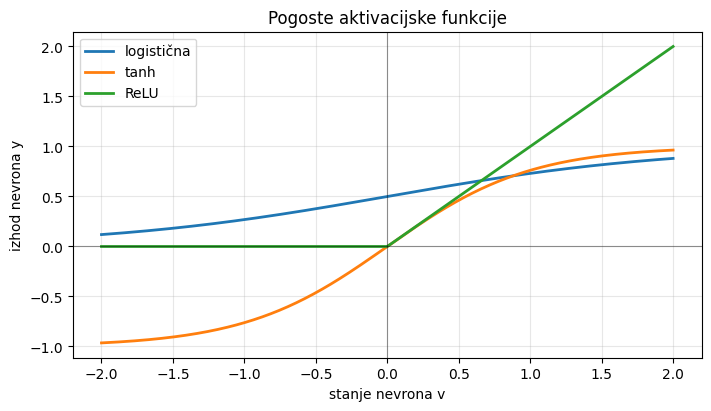

In [4]:
import numpy as np
import matplotlib.pyplot as plt

v = np.linspace(-2, 2, 400)
aktivacije = {
    "logistična": 1 / (1 + np.exp(-v)),
    "tanh": np.tanh(v),
    "ReLU": np.maximum(0, v),
}

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for ime, vrednosti in aktivacije.items():
    ax.plot(v, vrednosti, label=ime, linewidth=2)

ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.4)
ax.set_title("Pogoste aktivacijske funkcije")
ax.set_xlabel("stanje nevrona v")
ax.set_ylabel("izhod nevrona y")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


Število parametrov mreže hitro raste z velikostjo plasti. Če ima mreža tri vhodne spremenljivke, prvo skrito plast s petimi nevroni, drugo skrito plast z dvema nevronoma in en izhodni nevron, je število uteži z odmiki
$$
(3+1)\cdot 5 + (5+1)\cdot 2 + (2+1)\cdot 1 = 35.
$$
Povečevanje števila plasti in nevronov praviloma zmanjšuje pristranskost modela (torej se model lahko bolj približa učnim podatkom), hkrati pa povečuje varianco in posledično tudi nevarnost preprileganja. Zato pri učenju nevronskih mrež poleg arhitekture pazimo tudi na delitev podatkov, normalizacijo, regularizacijo in spremljanje napake na podatkih, ki niso bili uporabljeni za učenje.

## Vzvratno razširjanje napake

Pri nevronskih mrežah ne moremo več uporabiti normalnih enačb metode najmanjših kvadratov. Funkcija izgube je zaradi nelinearnih aktivacij praviloma nekonveksna, zato uteži učimo iterativno z gradientnimi metodami. Ključno vprašanje je, kako učinkovito izračunati gradient izgube po vseh utežeh v vseh plasteh.

Algoritem vzvratnega razširjanja napake je sistematična uporaba verižnega pravila. Naj bo $\mathcal{L}$ izguba za en učni primer. Za vsak nevron definiramo količino
$$
\delta_i^{(l)} = \frac{\partial \mathcal{L}}{\partial v_i^{(l)}},
$$
torej odvod izgube po stanju tega nevrona. Te količine imenujemo tudi napake nevronov. Ko poznamo $\delta^{(l)}$, je gradient po utežeh med prejšnjo in trenutno plastjo zelo preprost:
$$
\frac{\partial \mathcal{L}}{\partial W^{(l)}}
= \boldsymbol{y}^{(l-1)} (\boldsymbol{\delta}^{(l)})^T.
$$
Elementno to pomeni
$$
\frac{\partial \mathcal{L}}{\partial w_{ji}^{(l)}}
= y^{(l-1)}_j\,\delta_i^{(l)}.
$$
Utež se torej spremeni sorazmerno izhodu nevrona iz prejšnje plasti in napaki nevrona v trenutni plasti.

V izhodni plasti dobimo napako neposredno iz funkcije izgube. Pri regresiji s kvadratno izgubo
$$
\mathcal{L} = \frac{1}{2}\sum_i (y_i - \hat{y}_i)^2
$$
velja
$$
\delta_i^{(L+1)} = (\hat{y}_i - y_i)\,\phi'(v_i^{(L+1)}).
$$
Pri klasifikaciji je posebej pomembna kombinacija softmaxa in prečne entropije. Če je $\hat{\boldsymbol{p}}$ napovedana porazdelitev razredov, $\boldsymbol{y}$ pa vektor z eno enico pri pravem razredu, je
$$
\mathcal{L}(\boldsymbol{y}, \hat{\boldsymbol{p}})
= -\sum_{k=1}^{K}y_k\log \hat{p}_k.
$$
Za softmax in prečno entropijo se odvod po logitih poenostavi v
$$
\boldsymbol{\delta}^{(L+1)} = \hat{\boldsymbol{p}} - \boldsymbol{y}.
$$
To je razlog, da knjižnice, kot je PyTorch, klasifikacijski izgubi običajno podamo logite, ne že izračunanih verjetnosti.

Za skrite plasti uporabimo napake naslednje plasti. Če z $W^{(l+1)}_{\mathrm{brez\ odmikov}}$ označimo matriko $W^{(l+1)}$ brez vrstice, ki pripada odmikom, dobimo
$$
\boldsymbol{\delta}^{(l)}
= \left(W^{(l+1)}_{\mathrm{brez\ odmikov}}\boldsymbol{\delta}^{(l+1)}\right)
\odot \phi_l'(\boldsymbol{v}^{(l)}),
$$
kjer $\odot$ označuje množenje po komponentah. Tako lahko napake računamo nazaj: najprej izhodna plast, nato zadnja skrita plast, nato predzadnja in tako naprej do prve skrite plasti.

Celotna učna iteracija za en paket primerov je zato:

1. Izračun napovedi od vhodne proti izhodni plasti.
2. Izračun vrednosti funkcije izgube.
3. Izračun napak od izhodne proti vhodni plasti.
4. Izračun gradientov po utežeh.
5. Posodobitev uteži, na primer $W^{(l)} \leftarrow W^{(l)} - \eta\,\partial\mathcal{L}/\partial W^{(l)}$.

V PyTorchu korake 3 in 4 izvede avtomatsko odvajanje, ko pokličemo `loss.backward()`. To ne spremeni matematičnega ozadja delovanja gradientnega spusta, temveč nas razbremeni ročnega izpeljevanja gradientov za vsako plast posebej.


## Primer klasifikacije v PyTorchu

Za prvi primer uporabimo podatkovno množico `wine` iz paketa `scikit-learn`. Množica ima 178 primerov, 13 numeričnih napovednih spremenljivk in 3 razrede. Ker so napovedne spremenljivke merjene v različnih enotah, jih pred učenjem standardiziramo. To je pri nevronskih mrežah pomembno, ker gradientne metode lažje delujejo, kadar so vhodi primerljivih velikostnih redov.

Mreža bo imela dve skriti plasti in funkcije aktivacije ReLU. Izhodna plast ima tri nevrone, po enega za vsak razred. V kodi ne dodamo funkcije softmax na koncu modela, ker `nn.CrossEntropyLoss` pričakuje logite in interno združi `log_softmax` z negativno logaritemsko verjetnostjo pravega razreda.

In [ ]:
import torch
from torch import nn
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Nastavitev naključnega semena in omejitev števila niti za ponovljivost rezultatov
torch.manual_seed(42)
np.random.seed(42)
torch.set_num_threads(1)

# Naložimo podatkovno množico in jo pripravimo za učenje
wine = load_wine()
X = wine.data.astype(np.float32)
y = wine.target.astype(np.int64)

# 
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np).astype(np.float32)
X_test_np = scaler.transform(X_test_np).astype(np.float32)

X_train = torch.tensor(X_train_np)
y_train = torch.tensor(y_train_np)
X_test = torch.tensor(X_test_np)
y_test = torch.tensor(y_test_np)

# Definiramo nevronsko mrežo po plasteh
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, len(wine.target_names)),
)

# Definiramo funkcijo izgube in optimizator
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

# 
st_epoh = 300
epohe = []
izgube = []
tocnost_ucna = []
tocnost_testna = []

for epoha in range(1, st_epoh + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)
    loss.backward()
    optimizer.step()

    if epoha == 1 or epoha % 5 == 0:
        model.eval()
        with torch.no_grad():
            napoved_ucna = model(X_train).argmax(dim=1)
            napoved_testna = model(X_test).argmax(dim=1)

        epohe.append(epoha)
        izgube.append(loss.item())
        tocnost_ucna.append((napoved_ucna == y_train).float().mean().item())
        tocnost_testna.append((napoved_testna == y_test).float().mean().item())

model.eval()
with torch.no_grad():
    logits_test = model(X_test)
    napoved_testna = logits_test.argmax(dim=1).numpy()

tocnost = accuracy_score(y_test_np, napoved_testna)
print(f"Število učnih primerov: {len(y_train_np)}")
print(f"Število testnih primerov: {len(y_test_np)}")
print(f"Točnost na testnih podatkih: {tocnost:.3f}")


Število učnih primerov: 133
Število testnih primerov: 45
Točnost na testnih podatkih: 0.978


Zdaj pa še narišemo graf, ki nam ponazori kako se funkcija izgube in točnost (na učnih in testnih podatkih) spreminjata v procesu učenja.

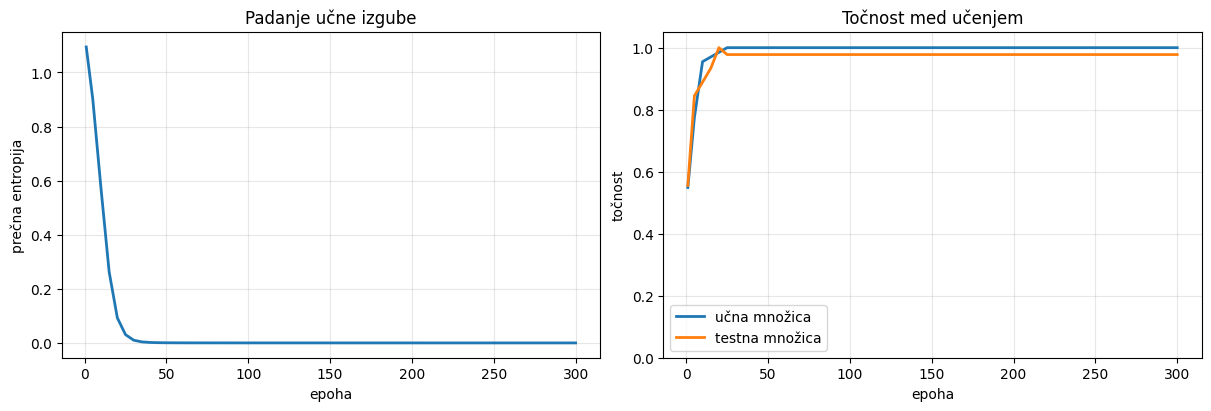

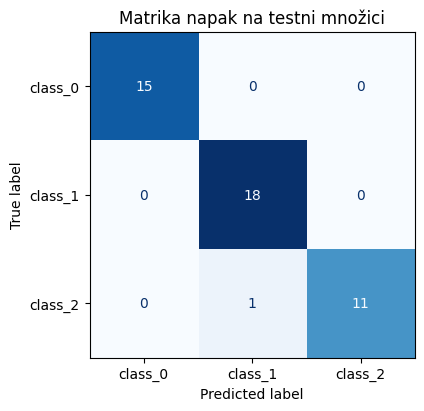

In [8]:
fig, osi = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

osi[0].plot(epohe, izgube, color="tab:blue", linewidth=2)
osi[0].set_title("Padanje učne izgube")
osi[0].set_xlabel("epoha")
osi[0].set_ylabel("prečna entropija")
osi[0].grid(alpha=0.3)

osi[1].plot(epohe, tocnost_ucna, label="učna množica", linewidth=2)
osi[1].plot(epohe, tocnost_testna, label="testna množica", linewidth=2)
osi[1].set_title("Točnost med učenjem")
osi[1].set_xlabel("epoha")
osi[1].set_ylabel("točnost")
osi[1].set_ylim(0.0, 1.05)
osi[1].grid(alpha=0.3)
osi[1].legend()

plt.show()

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(
    y_test_np,
    napoved_testna,
    display_labels=wine.target_names,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Matrika napak na testni množici")
plt.show()


Pri tako majhni množici rezultat ni stabilna ocena splošne zmogljivosti vseh nevronskih mrež. Namen primera je predvsem pokazati pravilen potek dela: delitev podatkov, standardizacija na učni množici, definicija modela, uporaba prečne entropije nad logiti, klic algoritma za vzvratno razširjanje napake `backward()` in posodobitev uteži z optimizatorjem.

Opazimo tudi, da PyTorch v modelu ne zahteva ročnega dodajanja vhodne komponente $1$ za odmik. Plast `nn.Linear` ima privzeto parameter `bias=True`, zato se odmik uči kot ločen parameter plasti.

## Konvolucijske nevronske mreže za slike

Pri slikah bi bila popolnoma povezana mreža hitro zelo velika. Če ima sivinska slika velikost $100\times100$, ima že vhodni vektor 10.000 komponent. Popolna povezava do skrite plasti s 100 nevroni bi imela več kot milijon uteži. Poleg tega popolnoma povezana plast ne izkoristi dejstva, da so sosednji piksli v sliki med seboj prostorsko povezani.

Konvolucijska plast namesto ločene uteži za vsak piksel uporablja majhen filter, na primer velikosti $3\times3$ ali $5\times5$, ki ga premika po sliki. V knjižnicah za globoko učenje se pri tem običajno računa navzkrižna korelacija, čeprav ji v praksi pogosto rečemo konvolucija:
$$
v_{i,j} = w_0 + \sum_{k=1}^{c}\sum_{m=1}^{c} w_{k,m}\,y_{i+k-1,j+m-1}.
$$
Enak filter se uporabi na vseh položajih, zato konvolucijska plast deli uteži čez sliko. Posledici sta manj parametrov in naravna občutljivost na lokalne vzorce, na primer robove, vogale in teksture.

Pogosta spremljevalka konvolucijske plasti je akumulacijska plast, na primer `max pooling`. Ta zmanjša prostorsko ločljivost predstavitve. Pri `2\times2` maksimumski akumulaciji z razmikom 2 se višina in širina predstavitve približno prepolovita. Tipična arhitektura za klasifikacijo slik zato izmenjuje konvolucije, nelinearne aktivacije in akumulacijo, nato pa končno predstavitev splošči in jo poda v eno ali več popolnoma povezanih plasti.

V PyTorchu imajo slike obliko `(število primerov, število kanalov, višina, širina)`. Sivinske slike imajo en kanal, barvne slike RGB pa tri kanale.


Za kratek primer uporabimo množico `digits` iz `scikit-learn`. Vsebuje slike ročno napisanih števk velikosti $8\times8$ in deset razredov. Slike so zelo majhne, zato je primer namenjen predvsem pravilnim dimenzijam in osnovni ideji konvolucijske arhitekture.


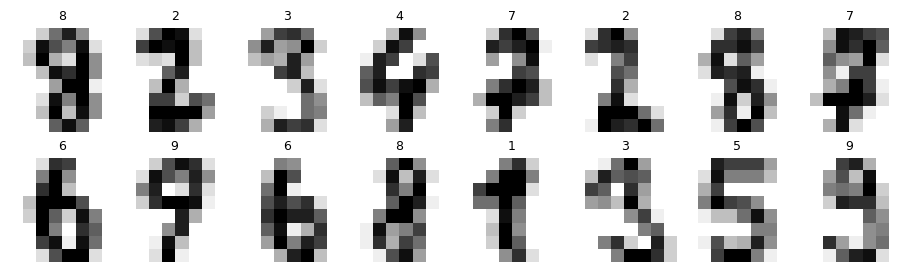

In [ ]:
from sklearn.datasets import load_digits

# Ponovno nastavimo naključno seme za ponovljivost rezultatov
torch.manual_seed(7)
np.random.seed(7)

# Naložimo podatkovno množico in jo pripravimo za učenje
digits = load_digits()
X_slike = digits.images.astype(np.float32) / 16.0
y_slike = digits.target.astype(np.int64)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_slike, y_slike, test_size=0.25, random_state=7, stratify=y_slike
)

# PyTorch pričakuje obliko: primeri, kanali, višina, širina.
X_train = torch.tensor(X_train_np[:, None, :, :])
X_test = torch.tensor(X_test_np[:, None, :, :])
y_train = torch.tensor(y_train_np)
y_test = torch.tensor(y_test_np)

# Prikažemo nekaj učnih primerov
fig, osi = plt.subplots(2, 8, figsize=(9, 2.6), constrained_layout=True)
for ax, slika, oznaka in zip(osi.ravel(), X_train_np[:16], y_train_np[:16]):
    ax.imshow(slika, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(str(oznaka), fontsize=9)
    ax.axis("off")
plt.show()


In [ ]:
class MajhnaKonvolucijskaMreza(nn.Module):
    def __init__(self):
        super().__init__()
        # V tej majhni konvolucijski mreži imamo dve konvolucijski plasti,
        # vsaka s funkcijo aktivacije ReLU in max poolingom,
        # ter na koncu linearno plast za klasifikacijo
        self.konvolucije = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.klasifikator = nn.Linear(16 * 2 * 2, 10)

    # V metodi forward najprej prehajamo skozi konvolucijske plasti
    # nato sploščimo izhod in ga pošljemo v linearno plast za klasifikacijo
    def forward(self, x):
        x = self.konvolucije(x)
        x = torch.flatten(x, start_dim=1)
        return self.klasifikator(x)

# Ustvarimo instanco konvolucijske mreže,
# definiramo funkcijo izgube in optimizator
cnn = MajhnaKonvolucijskaMreza()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.01)

st_epoh = 40
epohe_cnn = []
izgube_cnn = []
tocnosti_cnn = []

# Učimo konvolucijsko mrežo
# in spremljamo izgubo ter točnost na testnih podatkih
for epoha in range(1, st_epoh + 1):
    cnn.train()
    optimizer.zero_grad()
    logits = cnn(X_train)
    loss = loss_fn(logits, y_train)
    loss.backward()
    optimizer.step()

    cnn.eval()
    with torch.no_grad():
        napoved_testna = cnn(X_test).argmax(dim=1)
        testna_tocnost = (napoved_testna == y_test).float().mean().item()

    epohe_cnn.append(epoha)
    izgube_cnn.append(loss.item())
    tocnosti_cnn.append(testna_tocnost)

# Po učenju preverimo obliko predstavitev po konvolucijskih plasteh
cnn.eval()
with torch.no_grad():
    napoved_testna = cnn(X_test).argmax(dim=1).numpy()
    predstavitev = cnn.konvolucije(X_train[:1])

print(f"Oblika po konvolucijskih plasteh za eno sliko: {tuple(predstavitev.shape)}")
print(f"Točnost na testnih podatkih: {accuracy_score(y_test_np, napoved_testna):.3f}")


Oblika po konvolucijskih plasteh za eno sliko: (1, 16, 2, 2)
Testna točnost: 0.944


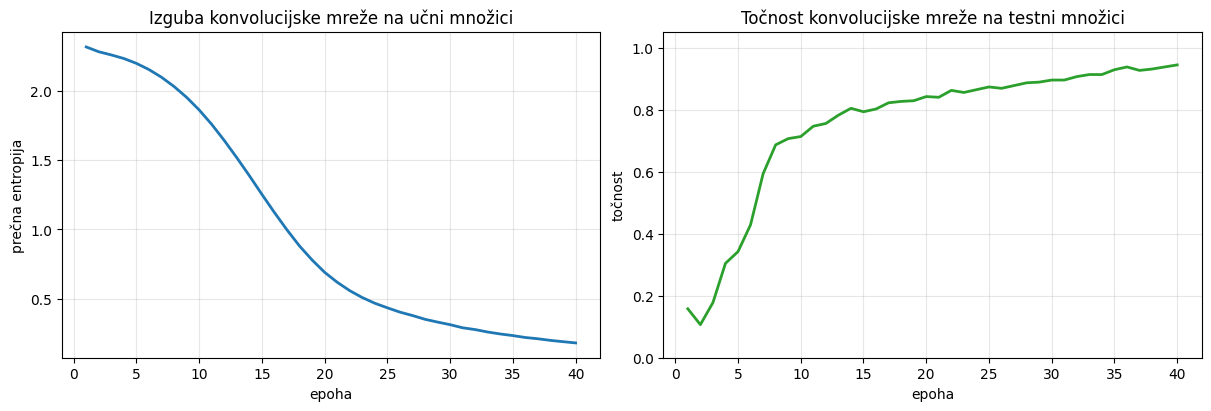

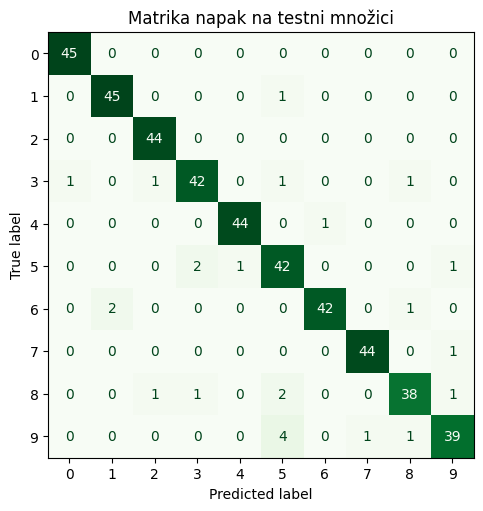

In [12]:
fig, osi = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

osi[0].plot(epohe_cnn, izgube_cnn, color="tab:blue", linewidth=2)
osi[0].set_title("Izguba konvolucijske mreže na učni množici")
osi[0].set_xlabel("epoha")
osi[0].set_ylabel("prečna entropija")
osi[0].grid(alpha=0.3)

osi[1].plot(epohe_cnn, tocnosti_cnn, color="tab:green", linewidth=2)
osi[1].set_title("Točnost konvolucijske mreže na testni množici")
osi[1].set_xlabel("epoha")
osi[1].set_ylabel("točnost")
osi[1].set_ylim(0.0, 1.05)
osi[1].grid(alpha=0.3)

plt.show()

fig, ax = plt.subplots(figsize=(5.5, 5), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(
    y_test_np,
    napoved_testna,
    display_labels=digits.target_names,
    cmap="Greens",
    colorbar=False,
    ax=ax,
)
ax.set_title("Matrika napak na testni množici")
plt.show()


V tem primeru prva konvolucijska plast ohrani velikost slik $8\times8$, ker uporabimo `padding=1`. Prva akumulacijska plast velikost zmanjša na $4\times4$, druga pa na $2\times2$. Ker ima druga konvolucijska plast 16 filtrov, je končna predstavitev ene slike oblike $16\times2\times2$, kar po sploščitvi pomeni 64 vhodov v zadnjo linearno plast.

Pri realnih slikovnih problemih so vhodne slike večje, arhitekture pa globlje. Osnovna ideja ostane enaka: lokalni filtri tvorijo vedno bolj abstraktne predstavitve slike, zadnje plasti pa iz teh predstavitev naredijo napoved razreda.

# Naloga za bonus točke

1. (5 točk, rok za oddajo: 15. maj) Zgradi in ovrednoti nevronsko mrežo za klasifikacijo podatkovne množice `digits` ali druge večrazredne podatkovne množice iz `scikit-learn`.

    Zahteve:

    1. Podatke razdeli na učno in testno množico. Če uporabljaš tabelarične podatke, napovedne spremenljivke standardiziraj tako, da parametre standardizacije oceniš samo na učni množici.
    1. Nauči vsaj dve različni arhitekturi nevronskih mrež tako, da spreminjaš število skritih plasti, število nevronov, funkcije aktivacije in stopnjo učenja.
    1. Za vsako arhitekturo prikaži spreminjanje vrednosti funkcije izgube in točnosti (na učni in testni množici) skozi epohe.
    1. Na testni množici poročaj točnost in matriko napak.
    1. V kratkem komentarju pojasni, katera arhitektura se je obnesla bolje in ali opaziš znake preprileganja.

    Dodatni izziv (za 3 bonus točke): za množico `digits` primerjaj popolnoma povezano mrežo z majhno konvolucijsko mrežo. Pri primerjavi upoštevaj tako točnost (na testnih podatkih) kot število parametrov modela.
<br/><br/>
